# Closed-loop adaptive GRAPE

This notebook keeps the same simplified style as `test_grape.ipynb` and `adaptive_grape_parameter_fit.ipynb`, but now combines the pieces into a small closed-loop calibration experiment.

The loop is:

1. optimize a pulse with GRAPE using the current calibrated model,
2. probe nearby pulses on the hidden true model with 500-shot binary measurements,
3. fit Hamiltonian parameters and the measurement response `A, B` from all measured data,
4. repeat, always warm-starting from the previous optimized pulse and previous fitted parameters.

The first phase uses unitary evolution for GRAPE and fitting. The second phase continues from that result and uses non-unitary evolution for GRAPE and fitting, while still keeping `T1/T2` fixed rather than fitting them.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

cwd = Path.cwd()
project_dir = cwd if (cwd / "grape.py").exists() else cwd / "Simplified_adaptive_grape"
repo_root = project_dir.parent
sys.path.insert(0, str(project_dir))
sys.path.insert(0, str(repo_root))

import toolbox as tbx
import grape


/home/user/codex_trial/hybrid_residual_grape/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experimental values and hidden true model

The nominal model is what GRAPE believes. The hidden true model is what generates the fake experimental measurements. It is intentionally close to the nominal model, but has small frequency shifts, amplitude miscalibrations, and slightly shorter coherence times.

The measured value is not the true photon probability directly. We first sample a 500-shot binomial distribution with probability `P_n`, then apply `observed = A*x + B`, with `0 -> 0.01` and `1 -> 0.93`, to mimic the long selective pulse plus readout imperfections.


In [2]:
config_path = repo_root / "configuration.json"
with config_path.open("r") as f:
    cfg = json.load(f)

# kHz -> MHz -> rad/us. We use a negative chi so H_disp = chi * n_cavity * |e><e|.
chi_nominal = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
cavity_self_kerr_nominal = 2 * jnp.pi * cfg["self_Kerr_kHz"] * 1e-3

qubit_T1_nominal = float(cfg["qubit_T1_us"])
qubit_T2_nominal = float(cfg["qubit_T2_us"])
cavity_T1_nominal = float(cfg["storage_T1_us"])
cavity_T2_nominal = float(cfg["storage_T2_us"])

mu_qub = 20.0
mu_cav = 20.0

# Hidden true model. Same soft mismatch as the parameter-fit notebook.
chi_true_shift_MHz = 0.001
qubit_freq_shift_MHz = 0.020
cavity_freq_shift_MHz = 0.040
cavity_self_kerr_true_MHz = -0.0007
qubit_amp_factor_true = 1.0005
cavity_amp_factor_true = 0.995

chi_true = chi_nominal + 2 * jnp.pi * chi_true_shift_MHz
qubit_shift_true = 2 * jnp.pi * qubit_freq_shift_MHz
cavity_shift_true = 2 * jnp.pi * cavity_freq_shift_MHz
cavity_self_kerr_true = 2 * jnp.pi * cavity_self_kerr_true_MHz

qubit_T1_true = 0.96 * qubit_T1_nominal
qubit_T2_true = 0.93 * qubit_T2_nominal
cavity_T1_true = 0.98 * cavity_T1_nominal
cavity_T2_true = 0.96 * cavity_T2_nominal

nominal_model = {
    "chi": chi_nominal,
    "qubit_shift": 0.0,
    "cavity_shift": 0.0,
    "cavity_self_kerr": cavity_self_kerr_nominal,
    "qubit_amp_factor": 1.0,
    "cavity_amp_factor": 1.0,
    "qubit_T1": qubit_T1_nominal,
    "qubit_T2": qubit_T2_nominal,
    "cavity_T1": cavity_T1_nominal,
    "cavity_T2": cavity_T2_nominal,
}

true_model = {
    "chi": chi_true,
    "qubit_shift": qubit_shift_true,
    "cavity_shift": cavity_shift_true,
    "cavity_self_kerr": cavity_self_kerr_true,
    "qubit_amp_factor": qubit_amp_factor_true,
    "cavity_amp_factor": cavity_amp_factor_true,
    "qubit_T1": qubit_T1_true,
    "qubit_T2": qubit_T2_true,
    "cavity_T1": cavity_T1_true,
    "cavity_T2": cavity_T2_true,
}

shots_per_pulse = 500
A_true = 0.92
B_true = 0.01

print("nominal chi [rad/us]:", float(chi_nominal))
print("true chi shift [MHz]:", chi_true_shift_MHz)
print("true qubit/cavity shifts [MHz]:", qubit_freq_shift_MHz, cavity_freq_shift_MHz)
print("true A, B:", A_true, B_true)


nominal chi [rad/us]: -4.145440537691808
true chi shift [MHz]: 0.001
true qubit/cavity shifts [MHz]: 0.02 0.04
true A, B: 0.92 0.01


## Pulse basis and simulation grid

The control is still `4 x 20` real B-spline coefficients. The two skipped splines at each end force every basis pulse to start and end at zero. With quadratic splines, at most three basis functions overlap at a given time.


B-splines on midpoints: (20, 130)
endpoint max: 0.0
max active B-splines: 3


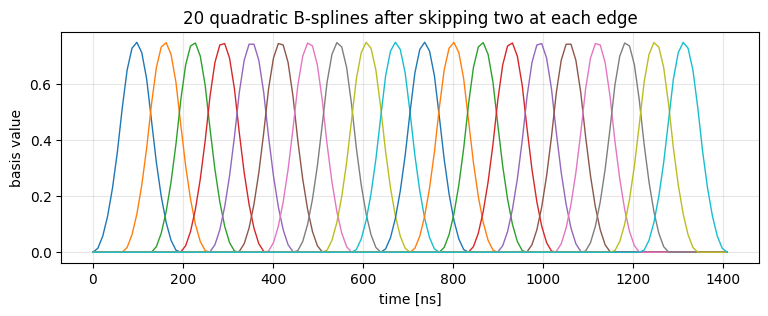

In [ ]:
N_cav = 25
target_n = 2 #fock state to prepare

param_clip = 2.0
n_channels = 4
n_total_bsplines = 24
spline_degree = 2
skip_left = 2
skip_right = 2
bspln_num = n_total_bsplines - skip_left - skip_right
assert bspln_num == 20

T_us = 1.408
Nt = 130

time_start = 0.0
time_end = T_us
time_edges = jnp.linspace(time_start, time_end, Nt + 1)
time_mids = 0.5 * (time_edges[1:] + time_edges[:-1])
time_intervals = time_edges[1:] - time_edges[:-1]

bspline_builder = tbx.setup_bspline_builder(
    time_start,
    time_end,
    n_total_bsplines,
    spline_degree,
    skip_left,
    skip_right,
)
bsplns_mids = jnp.asarray(bspline_builder(np.asarray(time_mids)))
bsplns_edges = jnp.asarray(bspline_builder(np.asarray(time_edges)))

print("B-splines on midpoints:", bsplns_mids.shape)
print("endpoint max:", float(jnp.max(jnp.abs(bsplns_edges[:, [0, -1]]))))
print("max active B-splines:", int(jnp.max(jnp.sum(bsplns_mids > 1e-12, axis=0))))

plt.figure(figsize=(9, 3))
for b in np.asarray(bsplns_edges):
    plt.plot(np.asarray(time_edges) * 1e3, b, lw=1)
plt.xlabel("time [ns]")
plt.ylabel("basis value")
plt.title("20 quadratic B-splines after skipping two at each edge")
plt.grid(alpha=0.3)
plt.show()


## Operators and simulators


In [4]:
a = tbx.tensor(tbx.identity(2), tbx.destroy(N_cav))
adag = tbx.hconj(a)
n_phot = adag @ a
n2_minus_n = n_phot @ n_phot - n_phot

sigz = tbx.tensor(tbx.sigma.z, tbx.identity(N_cav))
sigp = tbx.tensor(tbx.sigma.p, tbx.identity(N_cav))  # |e> -> |g>
sigm = tbx.hconj(sigp)                              # |g> -> |e>
one = tbx.identity(2 * N_cav)
qubit_excited = 0.5 * (one - sigz)

psi_init = tbx.tensor(tbx.basis(2, 0), tbx.basis(N_cav, 0))
rho_init = psi_init @ tbx.hconj(psi_init)

print("Hilbert dimension:", psi_init.shape[0])


Hilbert dimension: 50


In [5]:
def hamiltonian_tree(ctrl_coeffs, model):
    e_qub, e_cav = grape.controls_from_coefficients(ctrl_coeffs, bsplns_mids)
    e_qub = model["qubit_amp_factor"] * e_qub
    e_cav = model["cavity_amp_factor"] * 1j * jnp.conj(e_cav)

    H_drift = (
        model["chi"] * (n_phot @ qubit_excited)
        + 0.5 * model["cavity_self_kerr"] * n2_minus_n
        + model["cavity_shift"] * n_phot
        + model["qubit_shift"] * qubit_excited
    )

    return [
        [H_drift, 1.0, 1.0, 0.0],
        [sigp, mu_qub * e_qub, 1.0, 1.0],
        [adag, mu_cav * e_cav, 1.0, 1.0],
    ]


def collapse_ops(model):
    gamma_phi_qub = jnp.maximum(1.0 / model["qubit_T2"] - 0.5 / model["qubit_T1"], 0.0)
    gamma_phi_cav = jnp.maximum(1.0 / model["cavity_T2"] - 0.5 / model["cavity_T1"], 0.0)

    return [
        jnp.sqrt(1.0 / model["qubit_T1"]) * sigp,
        jnp.sqrt(2.0 * gamma_phi_qub) * qubit_excited,
        jnp.sqrt(1.0 / model["cavity_T1"]) * a,
        jnp.sqrt(2.0 * gamma_phi_cav) * n_phot,
    ]


def unitary_probability(ctrl_coeffs, model):
    psi_t = tbx.sesolve_htree(hamiltonian_tree(ctrl_coeffs, model), psi_init, time_intervals)
    return grape.fock_probability_from_state(psi_t[-1], N_cav, target_n)


def decay_probability(ctrl_coeffs, model):
    rho_final = tbx.mesolve_htree(
        hamiltonian_tree(ctrl_coeffs, model),
        collapse_ops(model),
        rho_init,
        time_intervals,
    )
    return grape.fock_probability_from_density(rho_final, N_cav, target_n)


## True experimental measurement

The true experiment always uses the hidden non-unitary model. The calibration algorithm never sees `p_true`; it only sees the noisy observed value.


In [6]:
@jax.jit
def true_physical_probability(ctrl_coeffs):
    return decay_probability(ctrl_coeffs, true_model)


def measure_true_experiment(ctrl_coeffs, key):
    p_true = true_physical_probability(ctrl_coeffs)
    successes = jax.random.binomial(key, n=shots_per_pulse, p=jnp.clip(p_true, 0.0, 1.0))
    shot_fraction = successes / shots_per_pulse
    observed = A_true * shot_fraction + B_true
    return observed, successes, p_true


## Calibrated model parameters

We fit only Hamiltonian and readout-response parameters:

- chi shift,
- qubit frequency shift,
- cavity self-Kerr,
- cavity frequency shift,
- qubit amplitude factor,
- cavity amplitude factor,
- `A` and `B` in the measurement response.

We do **not** fit `T1/T2`; those stay fixed at the nominal values. In the unitary phase they are unused. In the non-unitary phase they are included in the simulator but not adjusted.


In [7]:
def model_from_fit_raw(raw):
    chi_shift_MHz = 0.010 * jnp.tanh(raw[0])
    qubit_shift_MHz = 0.080 * jnp.tanh(raw[1])
    cavity_self_kerr_MHz = cfg["self_Kerr_kHz"] * 1e-3 + 0.0015 * jnp.tanh(raw[2])
    cavity_shift_MHz = 0.120 * jnp.tanh(raw[3])

    qubit_amp_factor = 1.0 + 0.010 * jnp.tanh(raw[4])
    cavity_amp_factor = 1.0 + 0.030 * jnp.tanh(raw[5])

    A_fit = 0.90 + 0.08 * jnp.tanh(raw[6])
    B_fit = 0.02 + 0.03 * jnp.tanh(raw[7])

    model = {
        "chi": chi_nominal + 2 * jnp.pi * chi_shift_MHz,
        "qubit_shift": 2 * jnp.pi * qubit_shift_MHz,
        "cavity_shift": 2 * jnp.pi * cavity_shift_MHz,
        "cavity_self_kerr": 2 * jnp.pi * cavity_self_kerr_MHz,
        "qubit_amp_factor": qubit_amp_factor,
        "cavity_amp_factor": cavity_amp_factor,
        "qubit_T1": qubit_T1_nominal,
        "qubit_T2": qubit_T2_nominal,
        "cavity_T1": cavity_T1_nominal,
        "cavity_T2": cavity_T2_nominal,
    }
    response = {"A": A_fit, "B": B_fit}
    return model, response


def predicted_observed_unitary(raw, ctrl_coeffs):
    model, response = model_from_fit_raw(raw)
    p_model = unitary_probability(ctrl_coeffs, model)
    return response["A"] * p_model + response["B"]


def predicted_observed_decay(raw, ctrl_coeffs):
    model, response = model_from_fit_raw(raw)
    p_model = decay_probability(ctrl_coeffs, model)
    return response["A"] * p_model + response["B"]


def parameter_summary(raw):
    model, response = model_from_fit_raw(raw)
    return {
        "chi_shift_MHz": float((model["chi"] - chi_nominal) / (2 * jnp.pi)),
        "qubit_shift_MHz": float(model["qubit_shift"] / (2 * jnp.pi)),
        "cavity_shift_MHz": float(model["cavity_shift"] / (2 * jnp.pi)),
        "self_kerr_MHz": float(model["cavity_self_kerr"] / (2 * jnp.pi)),
        "qubit_amp": float(model["qubit_amp_factor"]),
        "cavity_amp": float(model["cavity_amp_factor"]),
        "A": float(response["A"]),
        "B": float(response["B"]),
    }


## Local probing around the optimized pulse

Most pulses are extremely close to the GRAPE optimum; a smaller fraction are slightly farther away. This gives the fit local information without spending most shots on obviously bad pulses.


In [8]:
dataset_size_per_round = 500
very_local_noise_std = 0.0025
medium_local_noise_std = 0.0060
very_local_fraction = 0.90


def probe_local_dataset(ctrl_center, key, label):
    center_true = true_physical_probability(ctrl_center)
    center_expected_observed = A_true * center_true + B_true
    print(f"{label} center hidden true P_n: {float(center_true):.6f}")
    print(f"{label} center expected observed: {float(center_expected_observed):.6f}")

    n_very_local = int(dataset_size_per_round * very_local_fraction)
    noise_scales = jnp.concatenate([
        very_local_noise_std * jnp.ones((n_very_local,)),
        medium_local_noise_std * jnp.ones((dataset_size_per_round - n_very_local,)),
    ])

    key, noise_key, perm_key = jax.random.split(key, 3)
    noise_scales = noise_scales[jax.random.permutation(perm_key, dataset_size_per_round)]
    noise = noise_scales[:, None, None] * jax.random.normal(
        noise_key,
        (dataset_size_per_round, n_channels, bspln_num),
    )

    controls = grape.clip_coefficients(ctrl_center[None, :, :] + noise, param_clip)
    controls = controls.at[0].set(ctrl_center)

    observed_values = []
    true_values = []
    successes_values = []

    pbar = tqdm(range(dataset_size_per_round), desc=f"probe {label}", leave=False)
    for i in pbar:
        key, measure_key = jax.random.split(key)
        observed, successes, p_true = measure_true_experiment(controls[i], measure_key)
        observed_values.append(observed)
        true_values.append(p_true)
        successes_values.append(successes)
        pbar.set_postfix(obs=f"{float(observed):.4f}", true=f"{float(p_true):.4f}")

    observed_values = jnp.asarray(observed_values)
    true_values = jnp.asarray(true_values)
    successes_values = jnp.asarray(successes_values)

    print(f"{label} observed mean/std: {float(jnp.mean(observed_values)):.5f} / {float(jnp.std(observed_values)):.5f}")
    print(f"{label} true P_n mean/best: {float(jnp.mean(true_values)):.5f} / {float(jnp.max(true_values)):.5f}")
    return key, controls, observed_values, successes_values, true_values


def append_dataset(old_controls, old_observed, old_true, new_controls, new_observed, new_true):
    if old_controls is None:
        return new_controls, new_observed, new_true
    return (
        jnp.concatenate([old_controls, new_controls], axis=0),
        jnp.concatenate([old_observed, new_observed], axis=0),
        jnp.concatenate([old_true, new_true], axis=0),
    )


## GRAPE steps

The GRAPE optimizer only uses the calibrated model, never the hidden true model. The hidden true model is used afterward to create measurements.


In [9]:
unitary_grape_steps_per_round = 250
unitary_grape_learning_rate = 0.020
unitary_grape_optimizer = optax.adam(unitary_grape_learning_rate)

nonunitary_grape_steps_per_round = 140
nonunitary_grape_learning_rate = 0.002
nonunitary_grape_optimizer = optax.adam(nonunitary_grape_learning_rate)


@jax.jit
def unitary_grape_step(ctrl_coeffs, opt_state, fit_raw):
    def loss_fn(c):
        model, _ = model_from_fit_raw(fit_raw)
        p = unitary_probability(c, model)
        return 1.0 - p + grape.pulse_penalty(c), p

    (loss_value, p_value), grads = jax.value_and_grad(loss_fn, has_aux=True)(ctrl_coeffs)
    updates, opt_state = unitary_grape_optimizer.update(grads, opt_state)
    ctrl_coeffs = optax.apply_updates(ctrl_coeffs, updates)
    ctrl_coeffs = grape.clip_coefficients(ctrl_coeffs, param_clip)
    return ctrl_coeffs, opt_state, loss_value, p_value


@jax.jit
def nonunitary_grape_step(ctrl_coeffs, opt_state, fit_raw):
    def loss_fn(c):
        model, _ = model_from_fit_raw(fit_raw)
        p = decay_probability(c, model)
        return 1.0 - p + grape.pulse_penalty(c), p

    (loss_value, p_value), grads = jax.value_and_grad(loss_fn, has_aux=True)(ctrl_coeffs)
    updates, opt_state = nonunitary_grape_optimizer.update(grads, opt_state)
    ctrl_coeffs = optax.apply_updates(ctrl_coeffs, updates)
    ctrl_coeffs = grape.clip_coefficients(ctrl_coeffs, param_clip)
    return ctrl_coeffs, opt_state, loss_value, p_value


def run_unitary_grape(ctrl_start, fit_raw, label):
    ctrl = ctrl_start
    opt_state = unitary_grape_optimizer.init(ctrl)
    history = []
    pbar = tqdm(range(unitary_grape_steps_per_round), desc=f"unitary GRAPE {label}", leave=False)
    for _ in pbar:
        ctrl, opt_state, loss_value, p_value = unitary_grape_step(ctrl, opt_state, fit_raw)
        history.append(float(p_value))
        pbar.set_postfix(P_n=f"{float(p_value):.5f}")
    return ctrl, history


def run_nonunitary_grape(ctrl_start, fit_raw, label):
    ctrl = ctrl_start
    opt_state = nonunitary_grape_optimizer.init(ctrl)
    history = []
    pbar = tqdm(range(nonunitary_grape_steps_per_round), desc=f"nonunitary GRAPE {label}", leave=False)
    for _ in pbar:
        ctrl, opt_state, loss_value, p_value = nonunitary_grape_step(ctrl, opt_state, fit_raw)
        history.append(float(p_value))
        pbar.set_postfix(P_n=f"{float(p_value):.5f}")
    return ctrl, history


## Parameter fitting steps

The fit sees only measured values. It minimizes

`mean((predicted_observed(control) - measured_observed(control))**2)`.

The unitary phase uses `predicted_observed_unitary`; the non-unitary phase uses `predicted_observed_decay`. In both cases, the parameter vector is initialized from the previous round.


In [10]:
fit_steps_per_round = 180
fit_batch_size = 8
fit_learning_rate = 0.020
fit_optimizer = optax.adam(fit_learning_rate)


@jax.jit
def fit_step_unitary(fit_raw, opt_state, batch_controls, batch_observed):
    def loss_fn(raw):
        pred = jax.vmap(lambda c: predicted_observed_unitary(raw, c))(batch_controls)
        return jnp.mean((pred - batch_observed) ** 2), pred

    (loss_value, pred), grads = jax.value_and_grad(loss_fn, has_aux=True)(fit_raw)
    updates, opt_state = fit_optimizer.update(grads, opt_state)
    fit_raw = optax.apply_updates(fit_raw, updates)
    return fit_raw, opt_state, loss_value, jnp.mean(pred)


@jax.jit
def fit_step_decay(fit_raw, opt_state, batch_controls, batch_observed):
    def loss_fn(raw):
        pred = jax.vmap(lambda c: predicted_observed_decay(raw, c))(batch_controls)
        return jnp.mean((pred - batch_observed) ** 2), pred

    (loss_value, pred), grads = jax.value_and_grad(loss_fn, has_aux=True)(fit_raw)
    updates, opt_state = fit_optimizer.update(grads, opt_state)
    fit_raw = optax.apply_updates(fit_raw, updates)
    return fit_raw, opt_state, loss_value, jnp.mean(pred)


def fit_parameters(fit_raw, controls_seen, observed_seen, key, mode, label):
    opt_state = fit_optimizer.init(fit_raw)
    losses = []
    n_seen = controls_seen.shape[0]

    pbar = tqdm(range(fit_steps_per_round), desc=f"fit {mode} model {label}", leave=False)
    for _ in pbar:
        key, batch_key = jax.random.split(key)
        batch_idx = jax.random.choice(batch_key, n_seen, shape=(fit_batch_size,), replace=False)
        if mode == "unitary":
            fit_raw, opt_state, loss_value, mean_pred = fit_step_unitary(
                fit_raw,
                opt_state,
                controls_seen[batch_idx],
                observed_seen[batch_idx],
            )
        else:
            fit_raw, opt_state, loss_value, mean_pred = fit_step_decay(
                fit_raw,
                opt_state,
                controls_seen[batch_idx],
                observed_seen[batch_idx],
            )
        losses.append(float(loss_value))
        pbar.set_postfix(loss=f"{float(loss_value):.3e}", pred=f"{float(mean_pred):.4f}")

    print(f"{label} fit loss first/last: {losses[0]:.4e} / {losses[-1]:.4e}")
    print(f"{label} fitted parameters:", parameter_summary(fit_raw))
    return key, fit_raw, losses


## Initial pulse and shared state


In [11]:
key = jax.random.key(123)
key, subkey = jax.random.split(key)

initial_coeffs = 0.03 * jax.random.normal(subkey, (n_channels, bspln_num))
initial_coeffs = grape.clip_coefficients(initial_coeffs, param_clip)

fit_raw = jnp.zeros((8,))
controls_seen = None
observed_seen = None
true_seen = None

print("initial true P_n:", float(true_physical_probability(initial_coeffs)))
print("initial fitted parameters:", parameter_summary(fit_raw))


initial true P_n: 2.5524182200638484e-06
initial fitted parameters: {'chi_shift_MHz': 0.0, 'qubit_shift_MHz': 0.0, 'cavity_shift_MHz': 0.0, 'self_kerr_MHz': -0.0007211, 'qubit_amp': 1.0, 'cavity_amp': 1.0, 'A': 0.9, 'B': 0.02}


## Phase 1: closed-loop unitary adaptive GRAPE

Each round runs unitary GRAPE, measures local pulses on the hidden true open-system model, then refits Hamiltonian and measurement-response parameters using unitary evolution.


In [19]:
n_unitary_rounds = 20
ctrl_current = initial_coeffs
unitary_records = []
unitary_grape_histories = []
unitary_fit_histories = []

for round_index in range(n_unitary_rounds):
    label = f"unitary round {round_index:02d}"
    print("\n" + "=" * 80)
    print(label)
    print("starting parameters:", parameter_summary(fit_raw))

    ctrl_current, grape_history = run_unitary_grape(ctrl_current, fit_raw, label)
    unitary_grape_histories.append(grape_history)

    fitted_model, fitted_response = model_from_fit_raw(fit_raw)
    predicted_p = unitary_probability(ctrl_current, fitted_model)
    predicted_observed = fitted_response["A"] * predicted_p + fitted_response["B"]
    hidden_true_p = true_physical_probability(ctrl_current)
    expected_observed = A_true * hidden_true_p + B_true
    print(f"{label} GRAPE predicted unitary P_n: {float(predicted_p):.6f}")
    print(f"{label} model predicted measured value: {float(predicted_observed):.6f}")
    print(f"{label} hidden true P_n: {float(hidden_true_p):.6f}")
    print(f"{label} hidden expected measured value: {float(expected_observed):.6f}")

    key, new_controls, new_observed, new_successes, new_true = probe_local_dataset(ctrl_current, key, label)
    controls_seen, observed_seen, true_seen = append_dataset(
        controls_seen,
        observed_seen,
        true_seen,
        new_controls,
        new_observed,
        new_true,
    )
    print(f"total measured controls: {controls_seen.shape[0]}")

    key, fit_raw, fit_losses = fit_parameters(
        fit_raw,
        controls_seen,
        observed_seen,
        key,
        mode="unitary",
        label=label,
    )
    unitary_fit_histories.append(fit_losses)

    unitary_records.append({
        "round": round_index,
        "predicted_p": float(predicted_p),
        "predicted_observed": float(predicted_observed),
        "true_p": float(hidden_true_p),
        "expected_observed": float(expected_observed),
        "center_measured_observed": float(new_observed[0]),
        "data_observed_mean": float(jnp.mean(new_observed)),
        "data_true_mean": float(jnp.mean(new_true)),
        "fit_loss_last": float(fit_losses[-1]),
    })



unitary round 00
starting parameters: {'chi_shift_MHz': 0.004133065843954612, 'qubit_shift_MHz': 0.02146910004860767, 'cavity_shift_MHz': 0.036561857127177744, 'self_kerr_MHz': -0.00029050713555674054, 'qubit_amp': 1.0028514944073386, 'cavity_amp': 0.9977978934308637, 'A': 0.9051546344880711, 'B': 0.021610131590764088}


unitary round 00 GRAPE predicted unitary P_n: 0.984414
unitary round 00 hidden true P_n: 0.946323
unitary round 00 expected observed value: 0.880617
unitary round 00 center hidden true P_n: 0.946323
unitary round 00 center expected observed: 0.880617


unitary round 00 observed mean/std: 0.87810 / 0.01051
unitary round 00 true P_n mean/best: 0.94411 / 0.94682
total measured controls: 4000


unitary round 00 fit loss first/last: 1.1825e-03 / 2.9146e-05
unitary round 00 fitted parameters: {'chi_shift_MHz': 0.003936580035057895, 'qubit_shift_MHz': 0.008634767181333575, 'cavity_shift_MHz': 0.0352658835271491, 'self_kerr_MHz': -0.0003067930912051119, 'qubit_amp': 1.00129614165444, 'cavity_amp': 1.0004174275918145, 'A': 0.8806912972082693, 'B': 0.015196351736549353}

unitary round 01
starting parameters: {'chi_shift_MHz': 0.003936580035057895, 'qubit_shift_MHz': 0.008634767181333575, 'cavity_shift_MHz': 0.0352658835271491, 'self_kerr_MHz': -0.0003067930912051119, 'qubit_amp': 1.00129614165444, 'cavity_amp': 1.0004174275918145, 'A': 0.8806912972082693, 'B': 0.015196351736549353}


unitary round 01 GRAPE predicted unitary P_n: 0.993516
unitary round 01 hidden true P_n: 0.953396
unitary round 01 expected observed value: 0.887125
unitary round 01 center hidden true P_n: 0.953396
unitary round 01 center expected observed: 0.887125


...

unitary round 18 observed mean/std: 0.89305 / 0.00850
unitary round 18 true P_n mean/best: 0.96069 / 0.96330
total measured controls: 13000


unitary round 18 fit loss first/last: 9.6947e-05 / 1.3511e-05
unitary round 18 fitted parameters: {'chi_shift_MHz': 0.005172291788669008, 'qubit_shift_MHz': 0.009259228707820637, 'cavity_shift_MHz': 0.03658252763524105, 'self_kerr_MHz': -0.0005748045245352073, 'qubit_amp': 1.0022226411191988, 'cavity_amp': 0.9951397033578718, 'A': 0.8692082515115939, 'B': 0.029837220036593053}

unitary round 19
starting parameters: {'chi_shift_MHz': 0.005172291788669008, 'qubit_shift_MHz': 0.009259228707820637, 'cavity_shift_MHz': 0.03658252763524105, 'self_kerr_MHz': -0.0005748045245352073, 'qubit_amp': 1.0022226411191988, 'cavity_amp': 0.9951397033578718, 'A': 0.8692082515115939, 'B': 0.029837220036593053}


unitary round 19 GRAPE predicted unitary P_n: 0.999888
unitary round 19 hidden true P_n: 0.963373
unitary round 19 expected observed value: 0.896303
unitary round 19 center hidden true P_n: 0.963373
unitary round 19 center expected observed: 0.896303


unitary round 19 observed mean/std: 0.89440 / 0.00809
unitary round 19 true P_n mean/best: 0.96168 / 0.96362
total measured controls: 13500


unitary round 19 fit loss first/last: 7.6655e-05 / 1.2437e-04
unitary round 19 fitted parameters: {'chi_shift_MHz': 0.005377543448617058, 'qubit_shift_MHz': 0.013770657582699436, 'cavity_shift_MHz': 0.036200365986214504, 'self_kerr_MHz': -0.000653460412432808, 'qubit_amp': 1.0028721348483791, 'cavity_amp': 0.9942980315682658, 'A': 0.8653318579363994, 'B': 0.02875598863657123}


## Phase 2: closed-loop non-unitary adaptive GRAPE

This phase starts from the unitary result. It uses non-unitary GRAPE and non-unitary parameter fitting, but the fitted parameters are still only Hamiltonian and measurement-response parameters. The nominal `T1/T2` values are used but not fitted.


In [20]:
n_nonunitary_rounds = 20
nonunitary_records = []
nonunitary_grape_histories = []
nonunitary_fit_histories = []

for round_index in range(n_nonunitary_rounds):
    label = f"nonunitary round {round_index:02d}"
    print("\n" + "=" * 80)
    print(label)
    print("starting parameters:", parameter_summary(fit_raw))

    ctrl_current, grape_history = run_nonunitary_grape(ctrl_current, fit_raw, label)
    nonunitary_grape_histories.append(grape_history)

    fitted_model, fitted_response = model_from_fit_raw(fit_raw)
    predicted_p = decay_probability(ctrl_current, fitted_model)
    predicted_observed = fitted_response["A"] * predicted_p + fitted_response["B"]
    hidden_true_p = true_physical_probability(ctrl_current)
    expected_observed = A_true * hidden_true_p + B_true
    print(f"{label} GRAPE predicted decay P_n: {float(predicted_p):.6f}")
    print(f"{label} model predicted measured value: {float(predicted_observed):.6f}")
    print(f"{label} hidden true P_n: {float(hidden_true_p):.6f}")
    print(f"{label} hidden expected measured value: {float(expected_observed):.6f}")

    key, new_controls, new_observed, new_successes, new_true = probe_local_dataset(ctrl_current, key, label)
    controls_seen, observed_seen, true_seen = append_dataset(
        controls_seen,
        observed_seen,
        true_seen,
        new_controls,
        new_observed,
        new_true,
    )
    print(f"total measured controls: {controls_seen.shape[0]}")

    key, fit_raw, fit_losses = fit_parameters(
        fit_raw,
        controls_seen,
        observed_seen,
        key,
        mode="decay",
        label=label,
    )
    nonunitary_fit_histories.append(fit_losses)

    nonunitary_records.append({
        "round": round_index,
        "predicted_p": float(predicted_p),
        "predicted_observed": float(predicted_observed),
        "true_p": float(hidden_true_p),
        "expected_observed": float(expected_observed),
        "center_measured_observed": float(new_observed[0]),
        "data_observed_mean": float(jnp.mean(new_observed)),
        "data_true_mean": float(jnp.mean(new_true)),
        "fit_loss_last": float(fit_losses[-1]),
    })



nonunitary round 00
starting parameters: {'chi_shift_MHz': 0.005377543448617058, 'qubit_shift_MHz': 0.013770657582699436, 'cavity_shift_MHz': 0.036200365986214504, 'self_kerr_MHz': -0.000653460412432808, 'qubit_amp': 1.0028721348483791, 'cavity_amp': 0.9942980315682658, 'A': 0.8653318579363994, 'B': 0.02875598863657123}


nonunitary round 00 GRAPE predicted decay P_n: 0.966689
nonunitary round 00 hidden true P_n: 0.964285
nonunitary round 00 expected observed value: 0.897142
nonunitary round 00 center hidden true P_n: 0.964285
nonunitary round 00 center expected observed: 0.897142


nonunitary round 00 observed mean/std: 0.89581 / 0.00825
nonunitary round 00 true P_n mean/best: 0.96256 / 0.96443
total measured controls: 14000


nonunitary round 00 fit loss first/last: 8.2190e-04 / 6.4434e-05
nonunitary round 00 fitted parameters: {'chi_shift_MHz': 0.0055460746200270295, 'qubit_shift_MHz': 0.015587579077419653, 'cavity_shift_MHz': 0.03610562478395539, 'self_kerr_MHz': -0.0006548749733197319, 'qubit_amp': 1.0038222709412332, 'cavity_amp': 0.9958238631036148, 'A': 0.8910991922457087, 'B': 0.03707437236951139}

nonunitary round 01
starting parameters: {'chi_shift_MHz': 0.0055460746200270295, 'qubit_shift_MHz': 0.015587579077419653, 'cavity_shift_MHz': 0.03610562478395539, 'self_kerr_MHz': -0.0006548749733197319, 'qubit_amp': 1.0038222709412332, 'cavity_amp': 0.9958238631036148, 'A': 0.8910991922457087, 'B': 0.03707437236951139}


nonunitary round 01 GRAPE predicted decay P_n: 0.967133
nonunitary round 01 hidden true P_n: 0.964847
nonunitary round 01 expected observed value: 0.897659
nonunitary round 01 center hidden true P_n: 0.964847
nonunitary round 01 center expected observed: 0.897659


...

nonunitary round 18 observed mean/std: 0.89904 / 0.00786
nonunitary round 18 true P_n mean/best: 0.96692 / 0.96875
total measured controls: 23000


nonunitary round 18 fit loss first/last: 5.9328e-05 / 8.9323e-05
nonunitary round 18 fitted parameters: {'chi_shift_MHz': 0.007884993028145226, 'qubit_shift_MHz': 0.011101312894881152, 'cavity_shift_MHz': 0.03926191950622595, 'self_kerr_MHz': -0.0012572104596091788, 'qubit_amp': 1.0039751260817482, 'cavity_amp': 1.0002387155774635, 'A': 0.8853389598533146, 'B': 0.04160428867009211}

nonunitary round 19
starting parameters: {'chi_shift_MHz': 0.007884993028145226, 'qubit_shift_MHz': 0.011101312894881152, 'cavity_shift_MHz': 0.03926191950622595, 'self_kerr_MHz': -0.0012572104596091788, 'qubit_amp': 1.0039751260817482, 'cavity_amp': 1.0002387155774635, 'A': 0.8853389598533146, 'B': 0.04160428867009211}


nonunitary round 19 GRAPE predicted decay P_n: 0.970978
nonunitary round 19 hidden true P_n: 0.968704
nonunitary round 19 expected observed value: 0.901207
nonunitary round 19 center hidden true P_n: 0.968704
nonunitary round 19 center expected observed: 0.901207


nonunitary round 19 observed mean/std: 0.89950 / 0.00753
nonunitary round 19 true P_n mean/best: 0.96710 / 0.96896
total measured controls: 23500


nonunitary round 19 fit loss first/last: 1.0979e-04 / 1.2668e-04
nonunitary round 19 fitted parameters: {'chi_shift_MHz': 0.007928910059242875, 'qubit_shift_MHz': 0.014766407699105784, 'cavity_shift_MHz': 0.0369477485029256, 'self_kerr_MHz': -0.0012803148919116737, 'qubit_amp': 1.0046737072668621, 'cavity_amp': 1.0001447180798821, 'A': 0.8870556688669327, 'B': 0.041924332794349706}


## Diagnostics

The next plots separate two quantities that should not be mixed.

First, we compare the **measured value** of the optimized pulse: the model predicts `A_fit * P_model + B_fit`, while the hidden experiment returns a 500-shot measured value whose expectation is `A_true * P_true + B_true`.

Second, we compare the underlying **physical photon probability** `P_n`. This is a diagnostic quantity in simulation, not directly what the experiment reports. When `P_n` is close to 1, the last plot uses `1 - P_n` on a log scale so improvements near high fidelity are visible.


In [ ]:
from matplotlib.ticker import MaxNLocator


def record_array(records, name, fallback=None):
    values = []
    for r in records:
        if name in r:
            values.append(r[name])
        elif fallback is not None:
            values.append(fallback(r))
        else:
            values.append(np.nan)
    return np.asarray(values, dtype=float)


def predicted_measurement(records):
    # New runs store the per-round model-predicted measurement directly.
    # For older executed notebooks, reconstruct a useful approximation with
    # the final fitted A, B so the plotting cell can still be rerun immediately.
    _, final_response = model_from_fit_raw(fit_raw)
    final_A = float(final_response["A"])
    final_B = float(final_response["B"])
    return record_array(
        records,
        "predicted_observed",
        fallback=lambda r: final_A * r["predicted_p"] + final_B,
    )


def plot_measurement_comparison(ax, records, title):
    rounds = np.arange(len(records))
    model_meas = predicted_measurement(records)
    measured_center = record_array(
        records,
        "center_measured_observed",
        fallback=lambda r: r["expected_observed"],
    )
    expected_true = record_array(records, "expected_observed")

    ax.plot(rounds, model_meas, "o-", label="model predicted measured value")
    ax.plot(rounds, measured_center, "s-", label="simulated 500-shot measurement")
    ax.plot(rounds, expected_true, "k--", lw=1.2, label="hidden expected measured value")
    ax.set_title(title)
    ax.set_xlabel("closed-loop round")
    ax.set_ylabel("measured value")
    ax.set_ylim(0.0, 1.0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)


def plot_probability_comparison(ax, records, title):
    rounds = np.arange(len(records))
    ax.plot(rounds, record_array(records, "predicted_p"), "o-", label=f"model predicted P_{target_n}")
    ax.plot(rounds, record_array(records, "true_p"), "s-", label=f"hidden true P_{target_n}")
    ax.plot(rounds, record_array(records, "data_true_mean"), ".-", alpha=0.55, label="mean true P_n of local probes")
    ax.set_title(title)
    ax.set_xlabel("closed-loop round")
    ax.set_ylabel(f"P_{target_n}")
    ax.set_ylim(0.0, 1.02)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
plot_measurement_comparison(axes[0], unitary_records, "Optimization with unitary evolution")
plot_measurement_comparison(axes[1], nonunitary_records, "Optimization with non-unitary evolution")
fig.suptitle("Optimized pulse: model prediction vs simulated experimental measurement")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
plot_probability_comparison(axes[0], unitary_records, "Optimization with unitary evolution")
plot_probability_comparison(axes[1], nonunitary_records, "Optimization with non-unitary evolution")
fig.suptitle("Optimized pulse: model photon probability vs hidden true photon probability")
fig.tight_layout()
plt.show()

all_records = unitary_records + nonunitary_records
rounds = np.arange(len(all_records))
true_infidelity = np.maximum(1.0 - record_array(all_records, "true_p"), 1e-8)
model_infidelity = np.maximum(1.0 - record_array(all_records, "predicted_p"), 1e-8)

plt.figure(figsize=(9, 4))
plt.semilogy(rounds, true_infidelity, "s-", label=f"hidden true 1 - P_{target_n}")
plt.semilogy(rounds, model_infidelity, "o-", label=f"model predicted 1 - P_{target_n}")
if len(unitary_records) > 0 and len(nonunitary_records) > 0:
    boundary = len(unitary_records) - 0.5
    plt.axvline(boundary, color="0.35", ls="--", lw=1)
    ymax = plt.ylim()[1]
    plt.text(boundary, ymax, " switch to non-unitary optimization", va="top", ha="left", fontsize=9)
plt.xlabel("global closed-loop round")
plt.ylabel(f"infidelity 1 - P_{target_n}")
plt.title("Optimized pulse quality on a log infidelity scale")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

print("final fitted parameters:", parameter_summary(fit_raw))
print("final hidden true P_n:", float(true_physical_probability(ctrl_current)))
print("final expected observed value:", float(A_true * true_physical_probability(ctrl_current) + B_true))


# Dynamiqs double check

In [23]:
import dynamiqs as dq

# Independent dynamiqs mesolve check for the final optimized pulse ctrl_current.
# This uses a denser 4 ns grid and rebuilds the Hamiltonian independently from
# the toolbox solver used during GRAPE.

dt_check_ns = 4
T_ns = int(round(T_us * 1000))
t_edges_check_us = jnp.arange(0, T_ns + dt_check_ns, dt_check_ns) / 1000.0
t_mids_check_us = 0.5 * (t_edges_check_us[1:] + t_edges_check_us[:-1])
bsplns_check = jnp.asarray(bspline_builder(np.asarray(t_mids_check_us)))

Iq = dq.eye(2)
Ic = dq.eye(N_cav)

a_q = dq.tensor(dq.destroy(2), Ic)
a_c = dq.tensor(Iq, dq.destroy(N_cav))
a_q_dag = dq.dag(a_q)
a_c_dag = dq.dag(a_c)

n_q = a_q_dag @ a_q
n_c = a_c_dag @ a_c

psi0_dq = dq.tensor(dq.basis(2, 0), dq.basis(N_cav, 0))
rho0_dq = dq.todm(psi0_dq)
projector_n = dq.tensor(Iq, dq.todm(dq.basis(N_cav, target_n)))

method = dq.method.Tsit5(rtol=1e-8, atol=1e-10, max_steps=1_000_000)
options = dq.Options(save_states=True, progress_meter=True)



def dynamiqs_mesolve_probability(ctrl_coeffs, model, label):
    fields = jnp.asarray(ctrl_coeffs @ bsplns_check)

    eps_qub_I = model["qubit_amp_factor"] * fields[0]
    eps_qub_Q = model["qubit_amp_factor"] * fields[1]
    eps_cav_I = model["cavity_amp_factor"] * fields[2]
    eps_cav_Q = model["cavity_amp_factor"] * fields[3]

    H0_dq = (
        model["chi"] * (n_c @ n_q)
        + 0.5 * model["cavity_self_kerr"] * (a_c_dag @ a_c_dag @ a_c @ a_c)
        + model["cavity_shift"] * n_c
        + model["qubit_shift"] * n_q
    )

    H_qub_I = mu_qub * (a_q + a_q_dag)
    H_qub_Q = mu_qub * (1j * a_q - 1j * a_q_dag)

    H_cav_I = mu_cav * (1j * a_c_dag - 1j * a_c)
    H_cav_Q = mu_cav * (a_c_dag + a_c)

    gamma_phi_qub = jnp.maximum(1.0 / model["qubit_T2"] - 0.5 / model["qubit_T1"], 0.0)
    gamma_phi_cav = jnp.maximum(1.0 / model["cavity_T2"] - 0.5 / model["cavity_T1"], 0.0)

    jump_ops_dq = [
        jnp.sqrt(1.0 / model["qubit_T1"]) * a_q,
        jnp.sqrt(2.0 * gamma_phi_qub) * n_q,
        jnp.sqrt(1.0 / model["cavity_T1"]) * a_c,
        jnp.sqrt(2.0 * gamma_phi_cav) * n_c,
    ]

    H_t = (
        H0_dq
        + dq.pwc(t_edges_check_us, eps_qub_I, H_qub_I)
        + dq.pwc(t_edges_check_us, eps_qub_Q, H_qub_Q)
        + dq.pwc(t_edges_check_us, eps_cav_I, H_cav_I)
        + dq.pwc(t_edges_check_us, eps_cav_Q, H_cav_Q)
    )

    result = dq.mesolve(
        H=H_t,
        jump_ops=jump_ops_dq,
        rho0=rho0_dq,
        tsave=t_edges_check_us,
        exp_ops=[projector_n],
        method=method,
        options=options,
    )

    rho_final = result.states[-1]
    p_n = float(jnp.real(dq.expect(projector_n, rho_final)))
    print(f"{label}: dynamiqs mesolve P_{target_n} = {p_n:.8f}")
    return p_n, result



fitted_model, fitted_response = model_from_fit_raw(fit_raw)

p_fitted_dq, result_fitted_dq = dynamiqs_mesolve_probability(
    ctrl_current,
    fitted_model,
    "final pulse on fitted calibrated model",
)

p_true_dq, result_true_dq = dynamiqs_mesolve_probability(
    ctrl_current,
    true_model,
    "final pulse on hidden true model",
)

print()
print("toolbox fitted-model decay P_n:", float(decay_probability(ctrl_current, fitted_model)))
print("toolbox hidden-true decay P_n:", float(true_physical_probability(ctrl_current)))
print("expected observed value from dynamiqs true P_n:", float(A_true * p_true_dq + B_true))

|██████████| 100.0% ◆ elapsed 2.15s ◆ remaining 0.00ms     


final pulse on fitted calibrated model: dynamiqs mesolve P_2 = 0.96632742


|██████████| 100.0% ◆ elapsed 2.17s ◆ remaining 0.00ms     


final pulse on hidden true model: dynamiqs mesolve P_2 = 0.96445750

toolbox fitted-model decay P_n: 0.9704323086015545
toolbox hidden-true decay P_n: 0.9687036863858477
expected observed value from dynamiqs true P_n: 0.8973008996842197
